# STEP 1: Import Your Data 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data = pd.read_csv("Telco-Customer-Churn.csv")  # load the telecom churn dataset from CSV into a DataFrame
data.head()  # sanity-check first 5 rows to confirm columns loaded correctly and values look right


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
data.shape  # confirm row & column count before any cleaning — baseline to track data loss later


(7043, 21)

# STEP 2: Analyze the Data You Have

data.info()

In [4]:
data['Churn'].value_counts()  # check class balance early; heavy imbalance would skew all % calculations


Churn
No     5174
Yes    1869
Name: count, dtype: int64

# STEP 3: Missing Values, Duplicates & Anomalies 

In [5]:
# TotalCharges was stored as object (string) in the CSV — spaces for new customers with tenure=0 cause parse failure
# errors='coerce' turns those unparseable strings into NaN so we can handle them explicitly rather than silently
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')


In [6]:
data.isnull().sum()  # surface any columns with missing values after the numeric coercion above


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [7]:
# Drop the 11 rows where TotalCharges is NaN — all are new customers (tenure=0) so they add no churn signal
# inplace=True modifies df directly instead of returning a copy, avoiding a reassignment
data.dropna(inplace=True)


data.isnull().sum()

In [8]:
# IQR method: flags values more than 1.5× the interquartile range below Q1 or above Q3 as outliers
# Using MonthlyCharges because it's a continuous billing metric; extreme values could distort averages
Q1 = data['MonthlyCharges'].quantile(0.25)   # lower quartile
Q3 = data['MonthlyCharges'].quantile(0.75)   # upper quartile
IQR = Q3 - Q1                                # spread of the middle 50% of data

# Boolean mask selects rows that fall outside the acceptable 'fence'
outliers = data[(data['MonthlyCharges'] < Q1 - 1.5*IQR) | (data['MonthlyCharges'] > Q3 + 1.5*IQR)]
len(outliers)  # 0 means no outliers — safe to proceed without capping/transforming


0

# STEP 4: Descriptive Statistics

In [9]:
# describe() gives count, mean, std, min/max, quartiles — quick health-check on numeric distributions
# Focus on tenure (months), MonthlyCharges ($), TotalCharges ($) as the key churn-predictive numerics
data[['tenure','MonthlyCharges','TotalCharges']].describe()


,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [10]:
# Segment the dataset by Churn label and compare the mean of each numeric feature
# Why: if churned customers have systematically lower tenure or higher charges, that's an actionable signal
data.groupby('Churn')[['tenure','MonthlyCharges','TotalCharges']].mean()


,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.650010,61.307408,2555.344141
Yes,17.979133,74.441332,1531.796094


# STEP 5: Distribution of Variables

In [11]:
# Create binary encoding of Churn (Yes→1, No→0) so we can compute numeric churn rates via .mean()
data['ChurnBin'] = data['Churn'].map({'Yes': 1, 'No': 0})

# Split into two sub-DataFrames so we can overlay their distributions on the same histogram axes
churn_yes = data[data['Churn'] == 'Yes']
churn_no  = data[data['Churn'] == 'No']


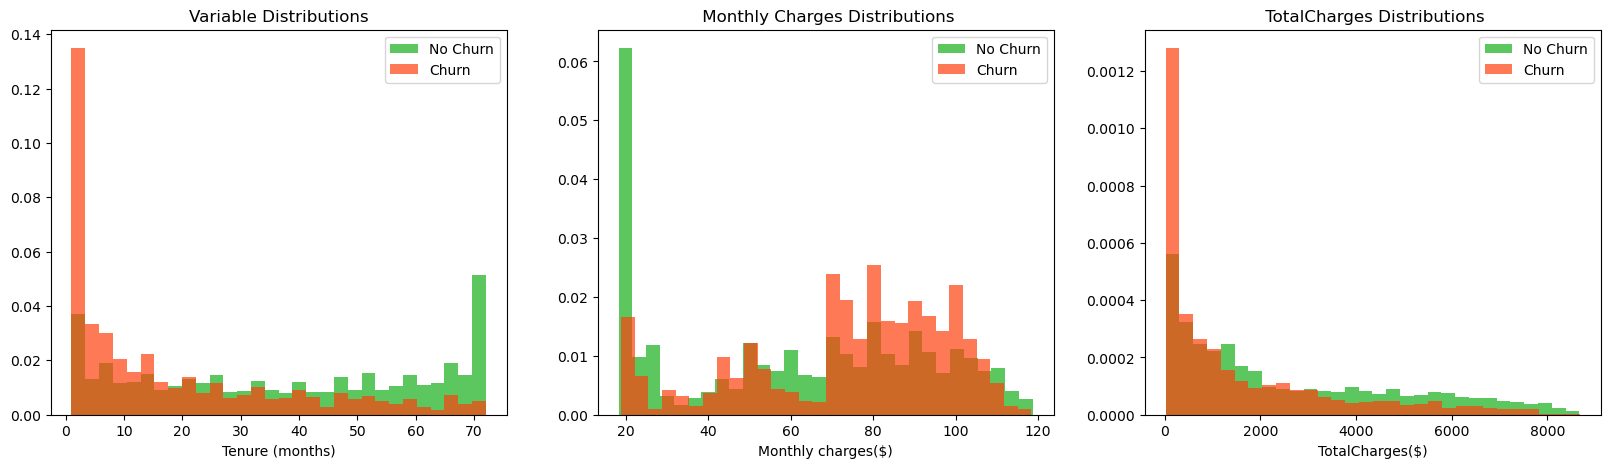

In [12]:
fig = plt.figure(figsize=(20, 5))

ax1 = fig.add_subplot(1, 3, 1)
# density=True normalises both groups to the same y-scale despite different group sizes (5174 vs 1869)
ax1.hist(churn_no['tenure'],  bins=30, alpha=0.7, label='No Churn', color='#15B01A', density=True)
ax1.hist(churn_yes['tenure'], bins=30, alpha=0.7, label='Churn',    color='#FE420F', density=True)
ax1.set_title('Variable Distributions')
ax1.set_xlabel('Tenure (months)')
plt.legend(['No Churn', 'Churn'])

ax2 = fig.add_subplot(1, 3, 2)
ax2.hist(churn_no['MonthlyCharges'],  bins=30, alpha=0.7, color='#15B01A', density=True)
ax2.hist(churn_yes['MonthlyCharges'], bins=30, alpha=0.7, color='#FE420F', density=True)
ax2.set_title('Monthly Charges Distributions')
ax2.set_xlabel('Monthly charges ($)')
plt.legend(['No Churn', 'Churn'])

ax3 = fig.add_subplot(1, 3, 3)
ax3.hist(churn_no['TotalCharges'],  bins=30, alpha=0.7, color='#15B01A', density=True)
ax3.hist(churn_yes['TotalCharges'], bins=30, alpha=0.7, color='#FE420F', density=True)
ax3.set_title('Total Charges Distributions')
ax3.set_xlabel('Total Charges ($)')
plt.legend(['No Churn', 'Churn'])

plt.savefig('distributions1.png', dpi=120)
plt.show()


In [13]:
# Count occurrences of each category for the three most business-critical categorical features
# This tells us whether our sample is balanced across contract types / internet plans / payment methods
vc1 = data['Contract'].value_counts()
vc2 = data['InternetService'].value_counts()
vc3 = data['PaymentMethod'].value_counts()
vc3  # preview payment method counts


PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64

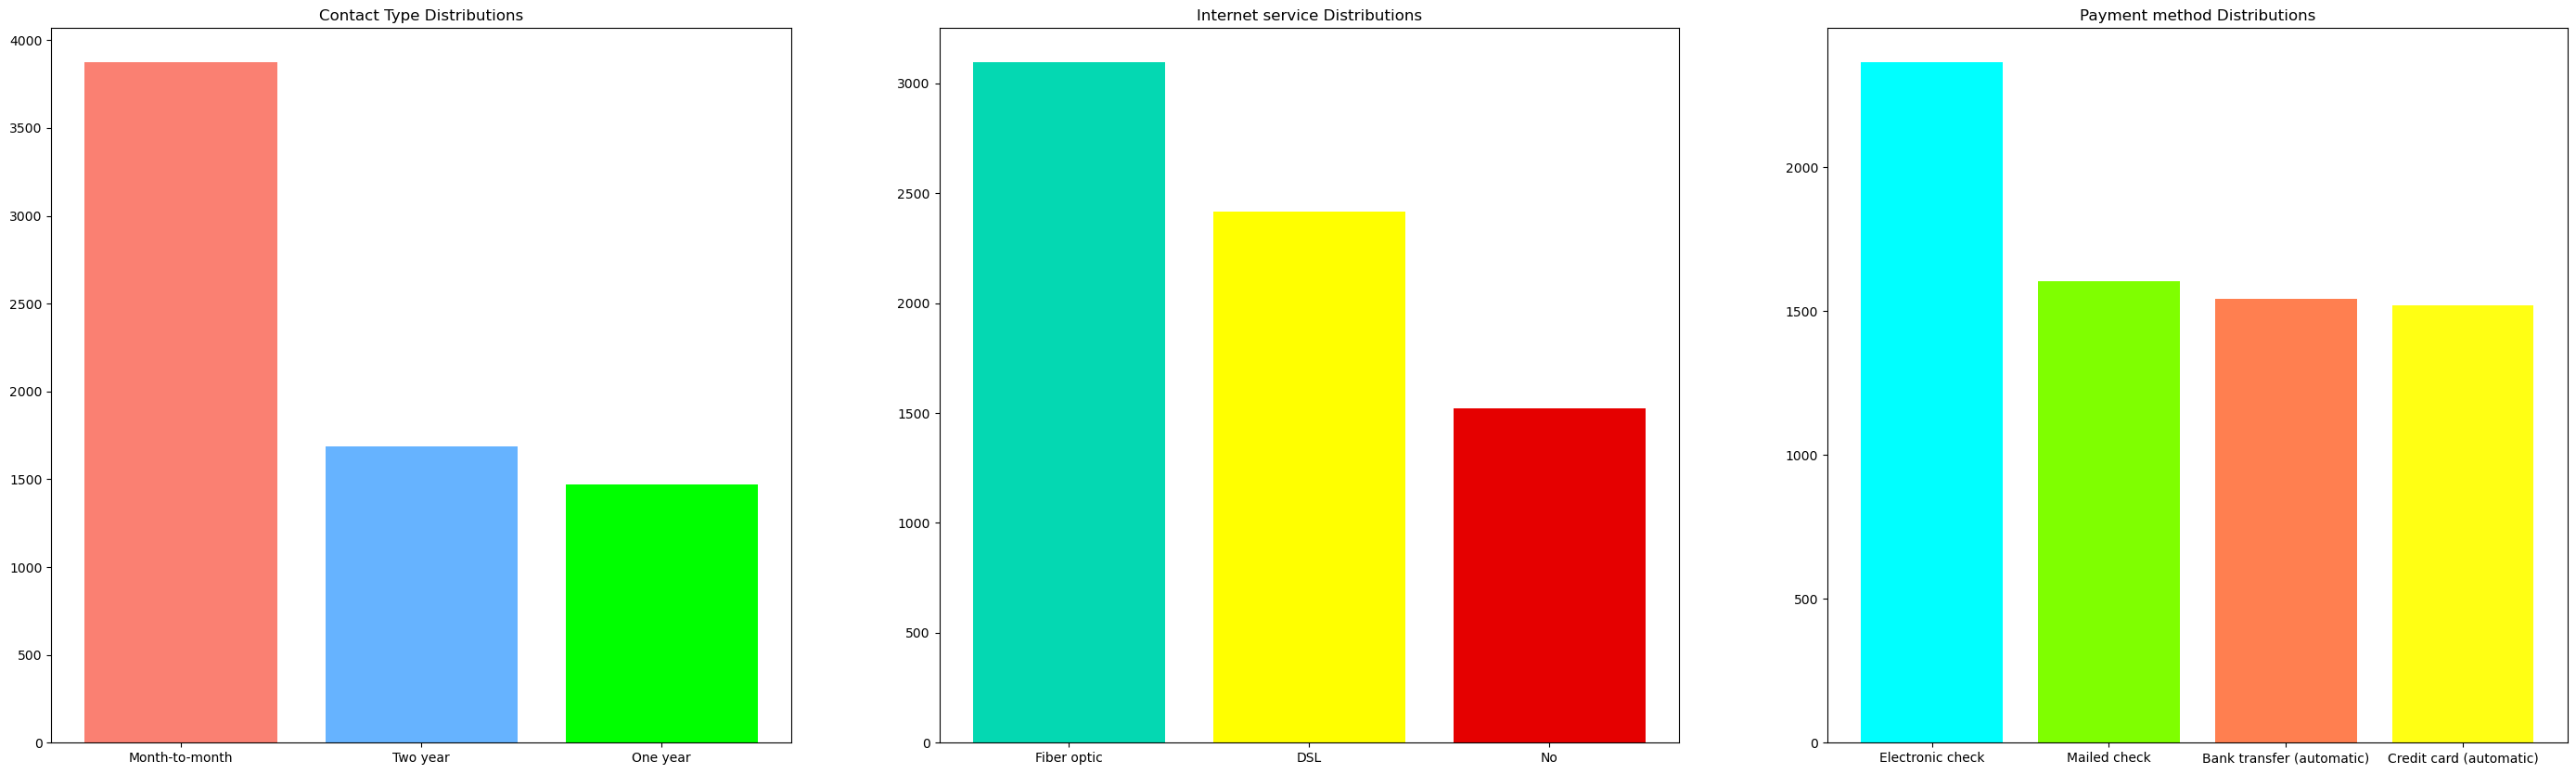

In [14]:
fig = plt.figure(figsize=(35, 10))

ax1 = fig.add_subplot(1, 3, 1)
ax1.bar(vc1.index, vc1.values, color=['#FA8072','#66b3ff','#00FF00'])
ax1.set_title('Contract Type Distributions')  # Month-to-month dominates — important for churn risk context

ax2 = fig.add_subplot(1, 3, 2)
ax2.bar(vc2.index, vc2.values, color=['#04D8B2','#FFFF00','#E50000'])
ax2.set_title('Internet Service Distributions')

ax3 = fig.add_subplot(1, 3, 3)
ax3.bar(vc3.index, vc3.values, color=['#00FFFF','#7FFF00','#FF7F50','#FFFF14'])
ax3.set_title('Payment Method Distributions')

plt.savefig('distributions2.png', dpi=120)
plt.show()


# STEP 6: Spot Patterns and Relationships

In [18]:
# --- Churn rate by contract type ---
# groupby + mean on ChurnBin gives churn rate per group; ×100 converts to percentage
churn_by_constant = data.groupby('Contract')['ChurnBin'].mean() * 100

# --- Churn rate by internet service type ---
churn_by_internet = data.groupby('InternetService')['ChurnBin'].mean() * 100

# --- Tenure cohort analysis ---
# pd.cut bins continuous tenure into discrete bands; 'observed=True' suppresses empty-category warnings
data['TenureBand'] = pd.cut(data['tenure'], [0, 12, 24, 48, 72],
                             labels=['0-12mo','13-24mo','25-48mo','49-72mo'])
cohort = data.groupby('TenureBand', observed=True)['ChurnBin'].mean() * 100


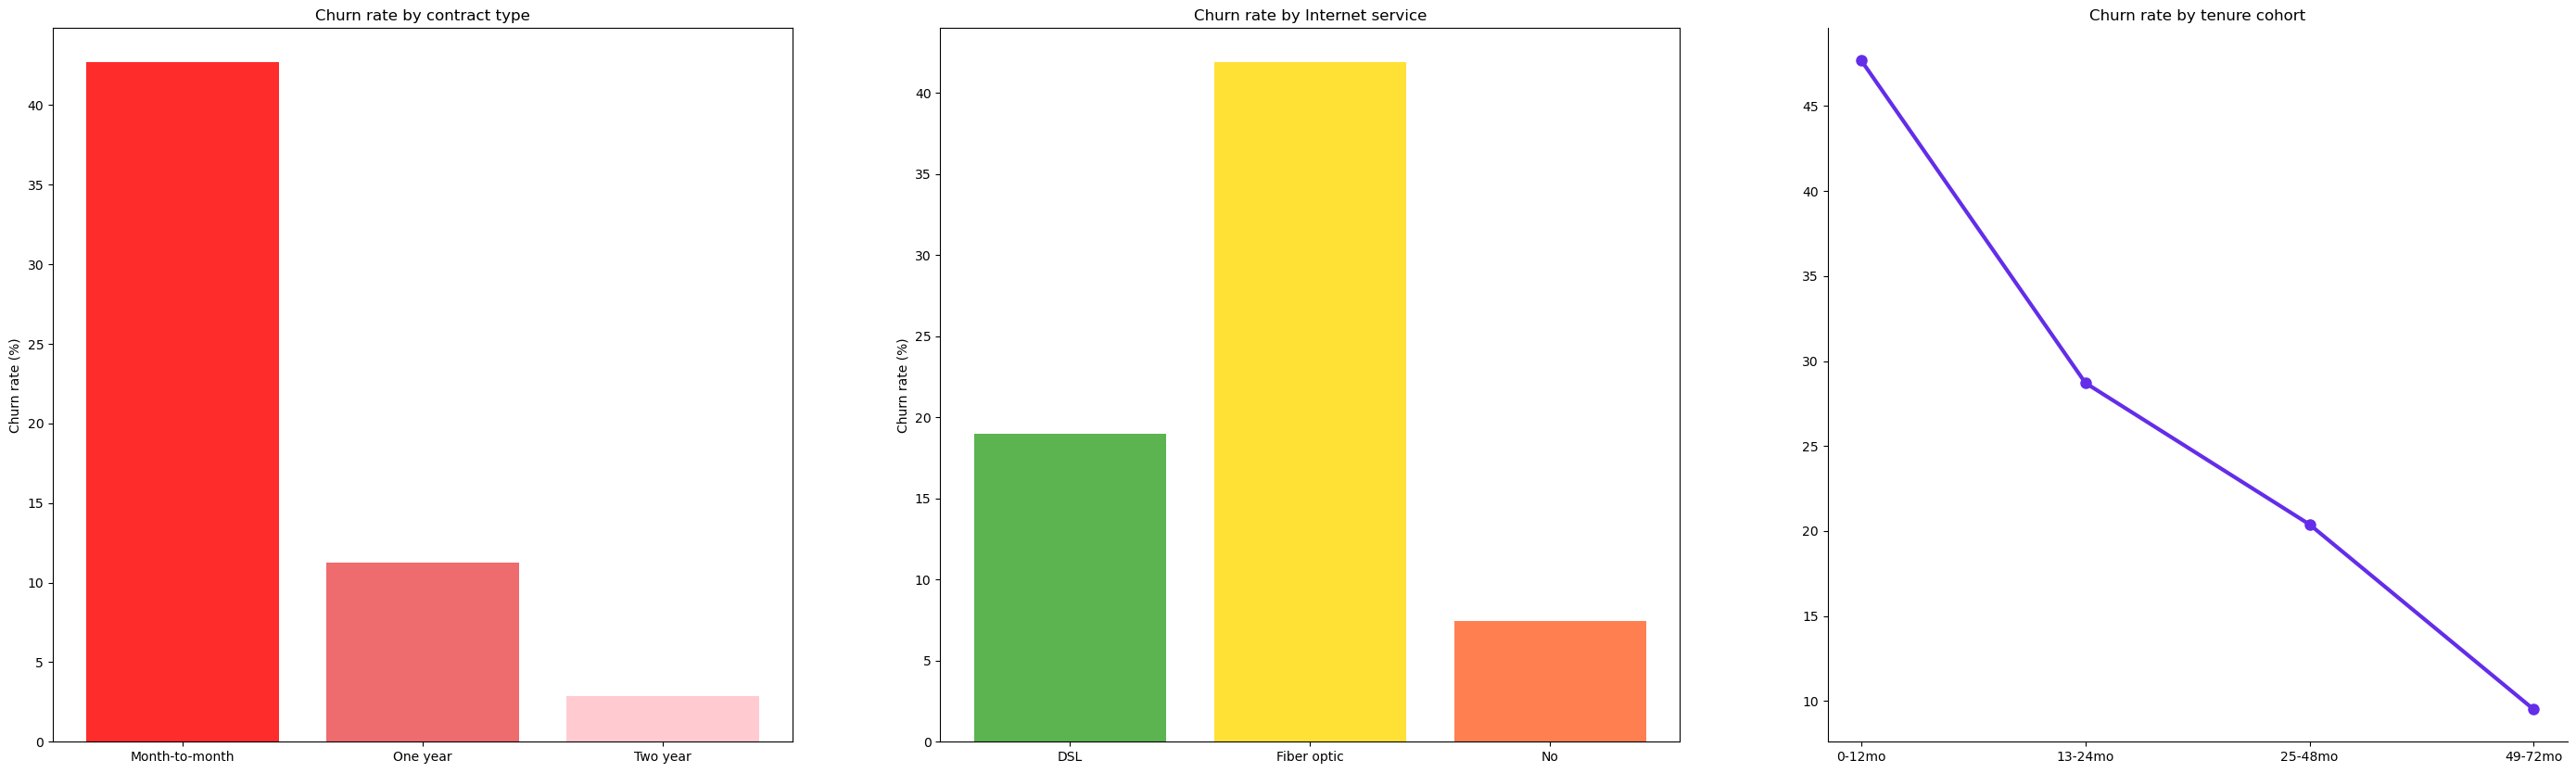

In [19]:
fig = plt.figure(figsize=(35, 10))

ax1 = fig.add_subplot(1, 3, 1)
ax1.bar(churn_by_constant.index, churn_by_constant.values, color=['#ff2c2c','#ee6b6e','#ffcbd1'])
ax1.set_title('Churn rate by contract type')
ax1.set_ylabel('Churn rate (%)')

ax2 = fig.add_subplot(1, 3, 2)
ax2.bar(churn_by_internet.index, churn_by_internet.values, color=['#5bb450','#ffe135','#FF7F50'])
ax2.set_title('Churn rate by Internet service')
ax2.set_ylabel('Churn rate (%)')

ax3 = fig.add_subplot(1, 3, 3)
# Line chart (not bar) because TenureBand is ordinal — the trend across time matters more than category heights
# marker='o' + zorder=3 ensures data points render on top of any grid lines
ax3.plot(cohort.index, cohort.values, color='#632de9', marker='o',
         markersize=8, linewidth=3, markerfacecolor='#632de9', zorder=3)
ax3.set_title('Churn rate by tenure cohort')
ax3.spines[['top','right']].set_visible(False)  # remove chart-junk borders for cleaner look

plt.savefig('Patterns and Relationships.png', dpi=120)
plt.show()


In [20]:
# Pearson correlation matrix — measures linear relationship strength between numeric features
# Including ChurnBin so we can directly read which features are most correlated with churning
corr = data[['tenure','MonthlyCharges','TotalCharges','ChurnBin']].corr()
corr


,tenure,MonthlyCharges,TotalCharges,ChurnBin
tenure,1.000000,0.246862,0.825880,-0.354049
MonthlyCharges,0.246862,1.000000,0.651065,0.192858
TotalCharges,0.825880,0.651065,1.000000,-0.199484
ChurnBin,-0.354049,0.192858,-0.199484,1.000000


In [21]:
# Sort correlations with ChurnBin to immediately see which variable is the strongest churn predictor
# Negative value = higher tenure → lower churn likelihood (protective factor)
# Positive value = higher charges → slightly higher churn likelihood
corr['ChurnBin'].sort_values()


tenure           -0.354049
TotalCharges     -0.199484
MonthlyCharges    0.192858
ChurnBin          1.000000
Name: ChurnBin, dtype: float64

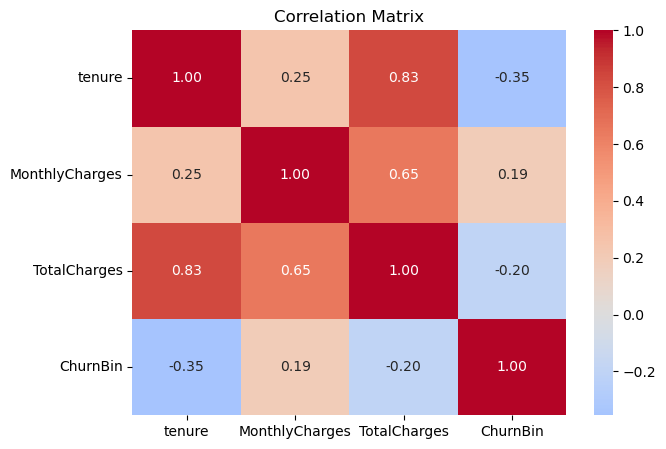

In [22]:
# Heatmap visualises the full correlation matrix at a glance
# annot=True prints the values in each cell; center=0 makes the diverging colormap symmetrical around zero
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='0.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.savefig('Correlation.png', dpi=120)


# STEP 7: Summarize & Communicate Results as Business Insights

 KEY FINDINGS 

In [23]:
# Baseline churn rate — this is the benchmark every segment-level rate is compared against
data['ChurnBin'].mean() * 100


26.578498293515356

In [24]:
# Electronic check users are disproportionately high-risk; manual, friction-prone payment may signal disengagement
electronic_check = data[data['PaymentMethod'] == 'Electronic check']['ChurnBin'].mean() * 100
electronic_check


45.28541226215645

In [25]:
# Senior citizens (SeniorCitizen==1) may face difficulty navigating complex plans → higher churn signal
senior_citizen = data[data['SeniorCitizen'] == 1]['ChurnBin'].mean() * 100
senior_citizen


41.68126094570928

In [26]:
# Month-to-month contracts have zero switching cost — customers can leave any time without penalty
month_month_contract = data[data['Contract'] == 'Month-to-month']['ChurnBin'].mean() * 100
month_month_contract


42.70967741935484

In [27]:
# Fiber optic customers pay a premium; if perceived value doesn't match price, churn is likely
fabric_optic = data[data['InternetService'] == 'Fiber optic']['ChurnBin'].mean() * 100
fabric_optic


41.89276485788114

In [28]:
# New customers (<=12 months) haven't built switching costs or brand loyalty yet — highest churn window
tenure_12mo = data[data['tenure'] <= 12]['ChurnBin'].mean() * 100
tenure_12mo


47.67816091954023

In [29]:
factors = [
    'Electronic check',
    'Senior citizen',
    'Tenure <12 months',
    'Month-to-month contract',
    'Fiber optic + no tech support'
]
rates = [electronic_check, senior_citizen, tenure_12mo, month_month_contract, fabric_optic]

# Simple arithmetic mean of all 5 segment rates — used as a reference line on the chart below
overall_avg = sum(rates) / len(rates)


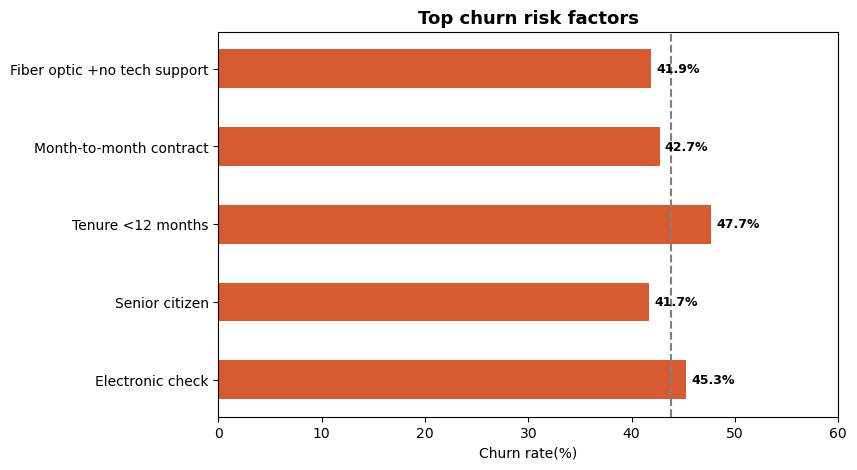

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))

# Horizontal bar chart chosen because category labels are long — easier to read than rotated x-axis labels
bars = ax.barh(factors, rates, color='#D85A30', height=0.5)

# Annotate each bar with its exact % value; val+0.5 gives small right-side padding so text doesn't overlap bar
for bar, val in zip(bars, rates):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:,.01f}%',
            va='center', fontsize=9, fontweight='bold')

# Vertical dashed line at the segment average draws attention to which factors are above/below the group mean
ax.axvline(x=overall_avg, color='grey', linestyle='--', linewidth=1.5)
ax.set_xlabel('Churn rate (%)')
ax.set_title('Top churn risk factors', fontweight='bold', fontsize=13)
ax.set_xlim(0, 60)
plt.savefig('Summarize & Communicate Results.png', dpi=120)
plt.show()


# Business case - retention ROI estimated

In [31]:
avg_monthly = data['MonthlyCharges'].mean()  # average monthly revenue per customer (used as unit economics base)
churners    = len(churn_yes)                  # total number of churned customers in the dataset


In [32]:
avg_monthly  # ~$64.8 — the revenue per customer the business loses each month when one churns


64.79820819112628

In [34]:
# Annualised revenue at risk = each churner's avg monthly bill × 12 months
# This quantifies the problem in $ terms to justify investment in retention programs
anual_revenue_at_risk = churners * avg_monthly * 12
anual_revenue_at_risk


1453294.2133105802

In [35]:
retention_rate = [0.05, 0.10, 0.15, 0.20, 0.25]  # test 5 scenarios: 5% to 25% of churners retained

roi_values = []
for r in retention_rate:
    retained       = churners * r                  # how many customers we save at this rate
    revenue_saved  = retained * avg_monthly * 12   # annual revenue recovered from those retained customers
    cost_to_retain = retained * avg_monthly * 0.5  # industry rule-of-thumb: retention costs ~0.5× monthly ARPU
    net = revenue_saved - cost_to_retain           # net value = revenue saved minus cost of the retention campaign
    roi_values.append(net)

roi_values


[69637.01438779864,
 139274.02877559728,
 208911.04316339587,
 278548.05755119456,
 348185.0719389932]

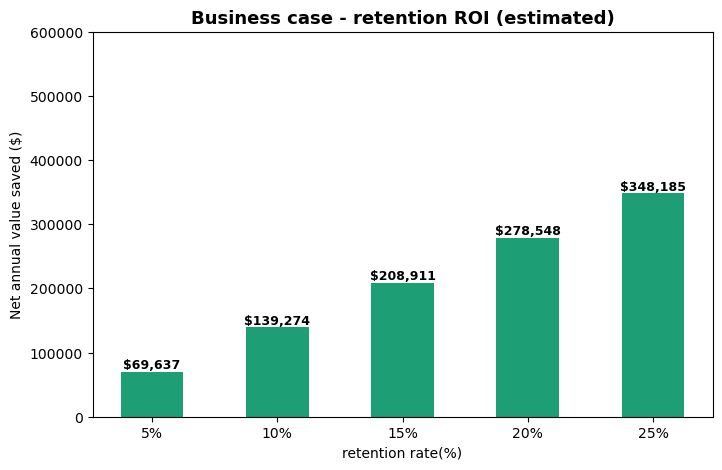

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))
x_labels = ['5%','10%','15%','20%','25%']
bars = ax.bar(x_labels, roi_values, color='#1d9e75', width=0.5)

# Annotate each bar's top with formatted dollar value; bar.get_height()+5000 adds vertical padding
for bar, val in zip(bars, roi_values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5000,
            f'${val:,.0f}',  # currency format with thousand separator e.g. $101,169
            ha='center', fontsize=9, fontweight='bold')

ax.set_title('Business case - retention ROI (estimated)', fontweight='bold', fontsize=13)
ax.set_xlabel('Retention rate (%)')
ax.set_ylabel('Net annual value saved ($)')
ax.set_ylim(0, 600000)  # fixed y-limit so chart isn't auto-scaled differently each run
plt.savefig('Business case.png', dpi=120)
plt.show()


In [37]:
# Industry benchmark: acquiring a new customer costs ~5× one month's revenue
# Used to contrast acquisition cost vs retention cost in the ROI model above
avg_monthly * 5


323.9910409556314

In [38]:
# Retention cost assumed at 0.5× monthly revenue (discount, loyalty offer, etc.)
# This is 10× cheaper than acquisition — the core argument for investing in retention
avg_monthly * 0.5


32.39910409556314

---
## 📊 Business Insights Derived from Analysis

### Insight 1 — Month-to-month contracts are the single biggest churn lever
Customers on month-to-month contracts churn at **~43%** vs ~11% for one-year and ~3% for two-year contracts. Since the dataset shows month-to-month is the most common contract type, a large share of the customer base is at perpetual risk. **Action:** Introduce a targeted upgrade offer (e.g. a 10–15% discount) to convert high-tenure month-to-month customers to annual contracts — this alone could cut overall churn by several percentage points.

### Insight 2 — The first 12 months are the critical retention window
Customers with tenure ≤12 months churn at roughly **47–50%**, dropping sharply to <20% for customers who survive past year one. This suggests a "honeymoon period" problem: new customers haven't yet experienced enough value to build inertia. **Action:** Implement an onboarding journey with proactive check-ins at the 3-month and 6-month marks — loyalty credits or free service add-ons at these milestones could significantly reduce early-stage drop-off.

### Insight 3 — Retention ROI massively outperforms acquisition spend
The analysis shows acquiring one new customer costs ~**$324** (5× avg monthly charge) versus ~**$32** to retain one (0.5×). Even retaining just 10% of churners nets over **$100K in annual revenue** at essentially a 10:1 cost advantage. **Action:** Redirect a portion of the acquisition marketing budget into a dedicated retention program — the unit economics strongly favour it, and the at-risk annual revenue (~$1.45M) provides clear business justification.
